In [1]:
# Task 9 - Outlier Detection and Removal (Simple Version)
# Dataset: adm_data.csv

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("adm_data.csv")

# Remove extra spaces from column names
df.columns = [c.strip() for c in df.columns]

# Drop Serial No. column since it is just an ID, not a real feature
df = df.drop(columns=["Serial No."])

df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


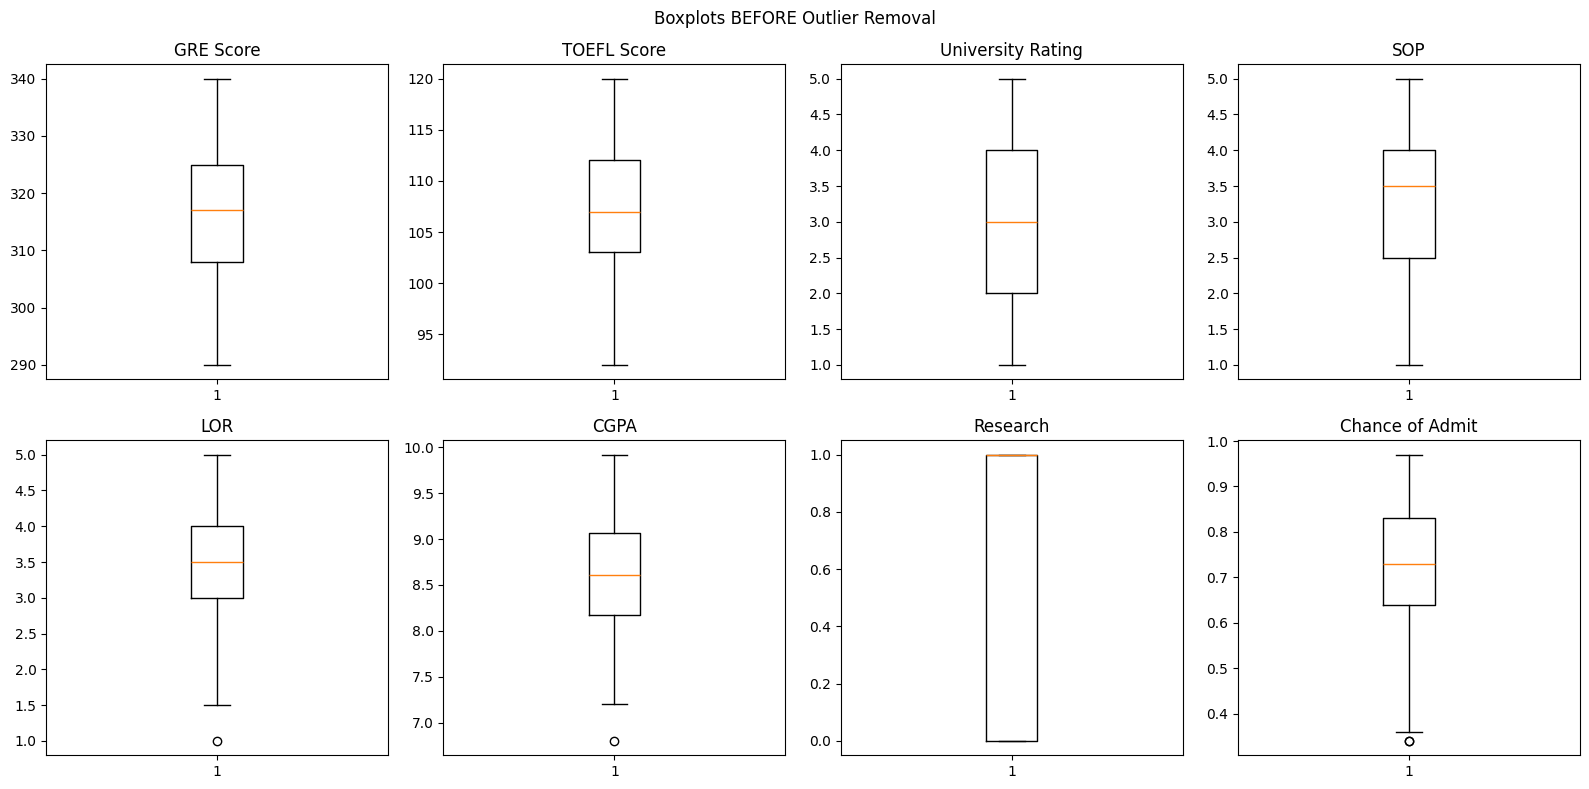

In [2]:
# Step 1: Visualize outliers using boxplots (BEFORE removing anything)
# Any dot outside the whiskers is a possible outlier

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.suptitle("Boxplots BEFORE Outlier Removal")
plt.tight_layout()
plt.show()

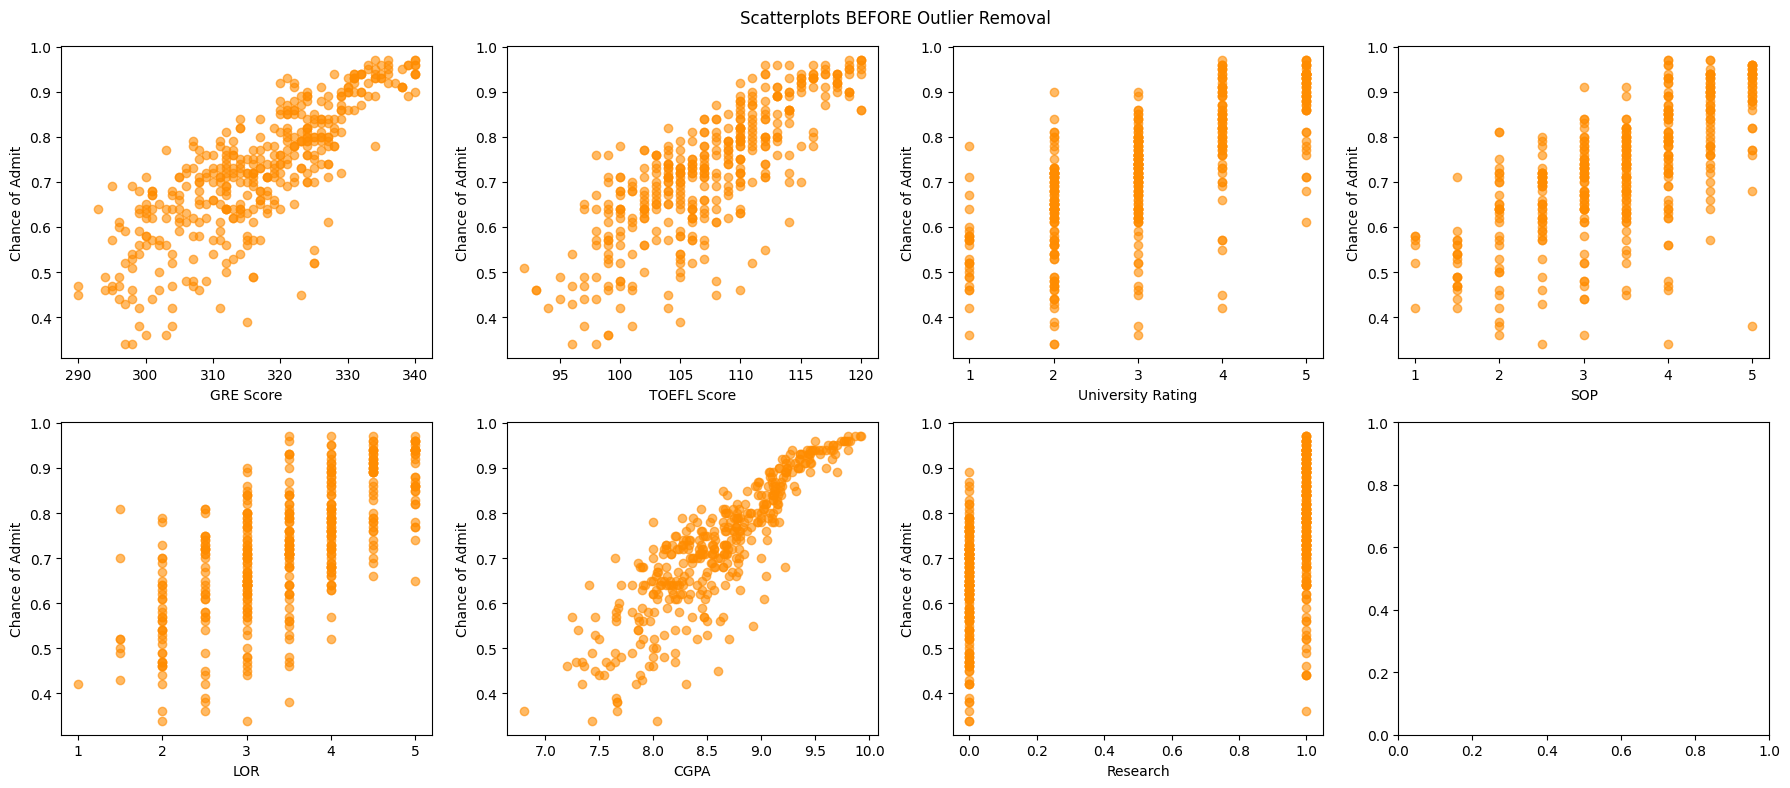

In [3]:
# Step 2: Visualize outliers using scatterplots (BEFORE removing anything)
# Points far away from the general trend line are possible outliers

features = [c for c in df.columns if c != "Chance of Admit"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df["Chance of Admit"], alpha=0.6, color="darkorange")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Chance of Admit")

plt.suptitle("Scatterplots BEFORE Outlier Removal")
plt.tight_layout()
plt.show()

In [4]:
# Step 3: Detect outliers using the IQR (Interquartile Range) technique
#
# How the IQR technique works:
# 1. Q1 = 25th percentile of the column, Q3 = 75th percentile of the column
# 2. IQR = Q3 - Q1  (this measures the "middle spread" of the data)
# 3. Any value below (Q1 - 1.5*IQR) or above (Q3 + 1.5*IQR) is treated as an outlier
# This is a simple, widely used statistical rule (no complex math needed)

def get_outlier_bounds(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Count outliers in each column before removing them
for col in df.columns:
    lower, upper = get_outlier_bounds(df, col)
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outlier(s) found (valid range {lower:.2f} to {upper:.2f})")

GRE Score: 0 outlier(s) found (valid range 282.50 to 350.50)
TOEFL Score: 0 outlier(s) found (valid range 89.50 to 125.50)
University Rating: 0 outlier(s) found (valid range -1.00 to 7.00)
SOP: 0 outlier(s) found (valid range 0.25 to 6.25)
LOR: 1 outlier(s) found (valid range 1.50 to 5.50)
CGPA: 1 outlier(s) found (valid range 6.83 to 10.40)
Research: 0 outlier(s) found (valid range -1.50 to 2.50)
Chance of Admit: 2 outlier(s) found (valid range 0.36 to 1.11)


In [5]:
# Step 4: FIX the outliers by REMOVING those rows (simple removal technique)
# We keep only the rows where every column value is inside its normal IQR range

df_clean = df.copy()

for col in df_clean.columns:
    lower, upper = get_outlier_bounds(df, col)   # bounds based on original data
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("Rows before removing outliers:", df.shape[0])
print("Rows after removing outliers :", df_clean.shape[0])
print("Rows removed                 :", df.shape[0] - df_clean.shape[0])

Rows before removing outliers: 400
Rows after removing outliers : 396
Rows removed                 : 4


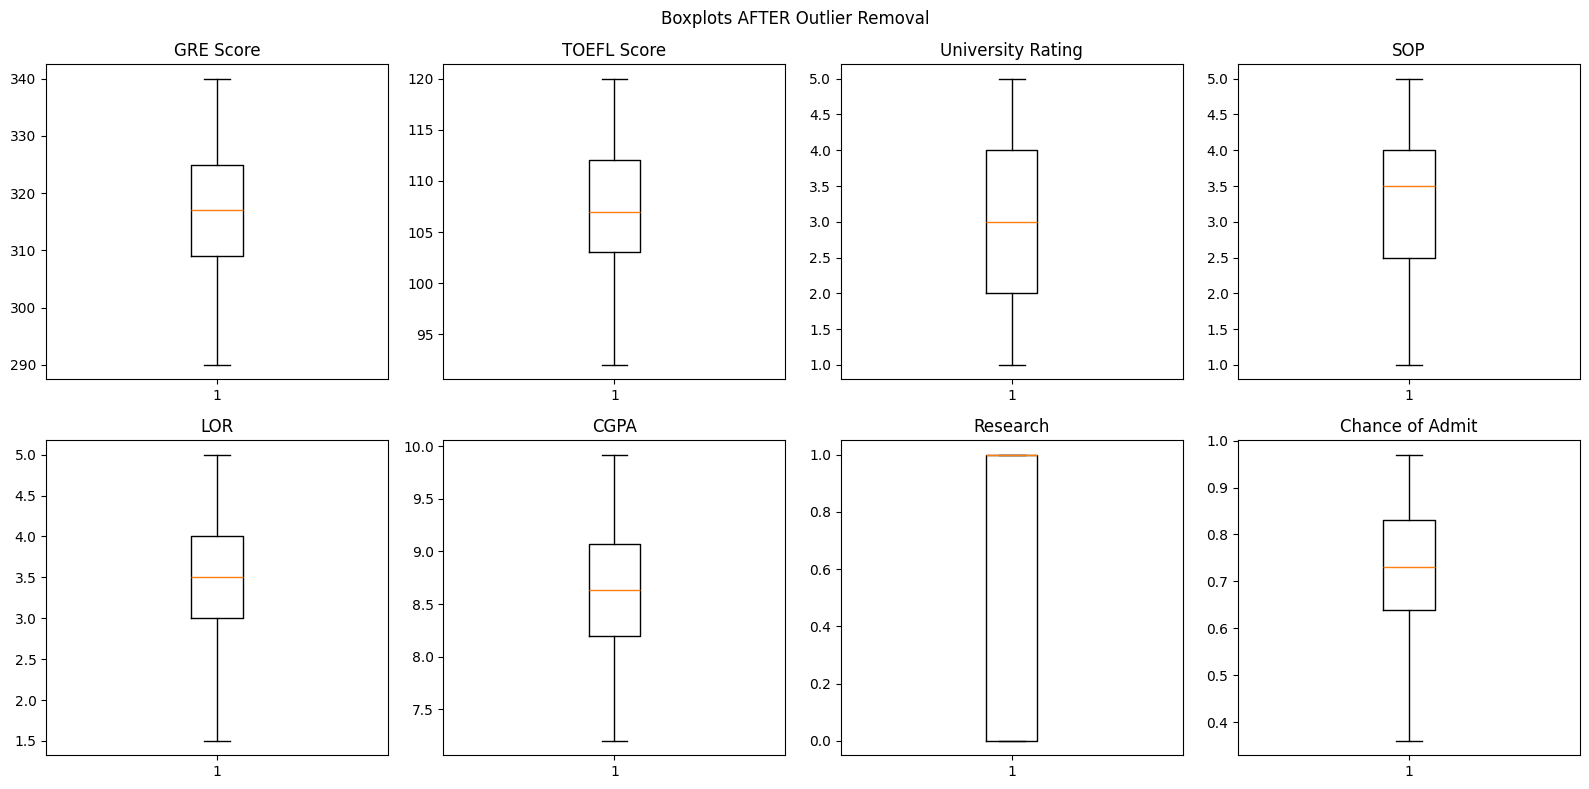

In [6]:
# Step 5: Visualize the data again AFTER removing outliers
# The boxplots should look cleaner with fewer/no extreme points

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    axes[i].boxplot(df_clean[col])
    axes[i].set_title(col)

plt.suptitle("Boxplots AFTER Outlier Removal")
plt.tight_layout()
plt.show()

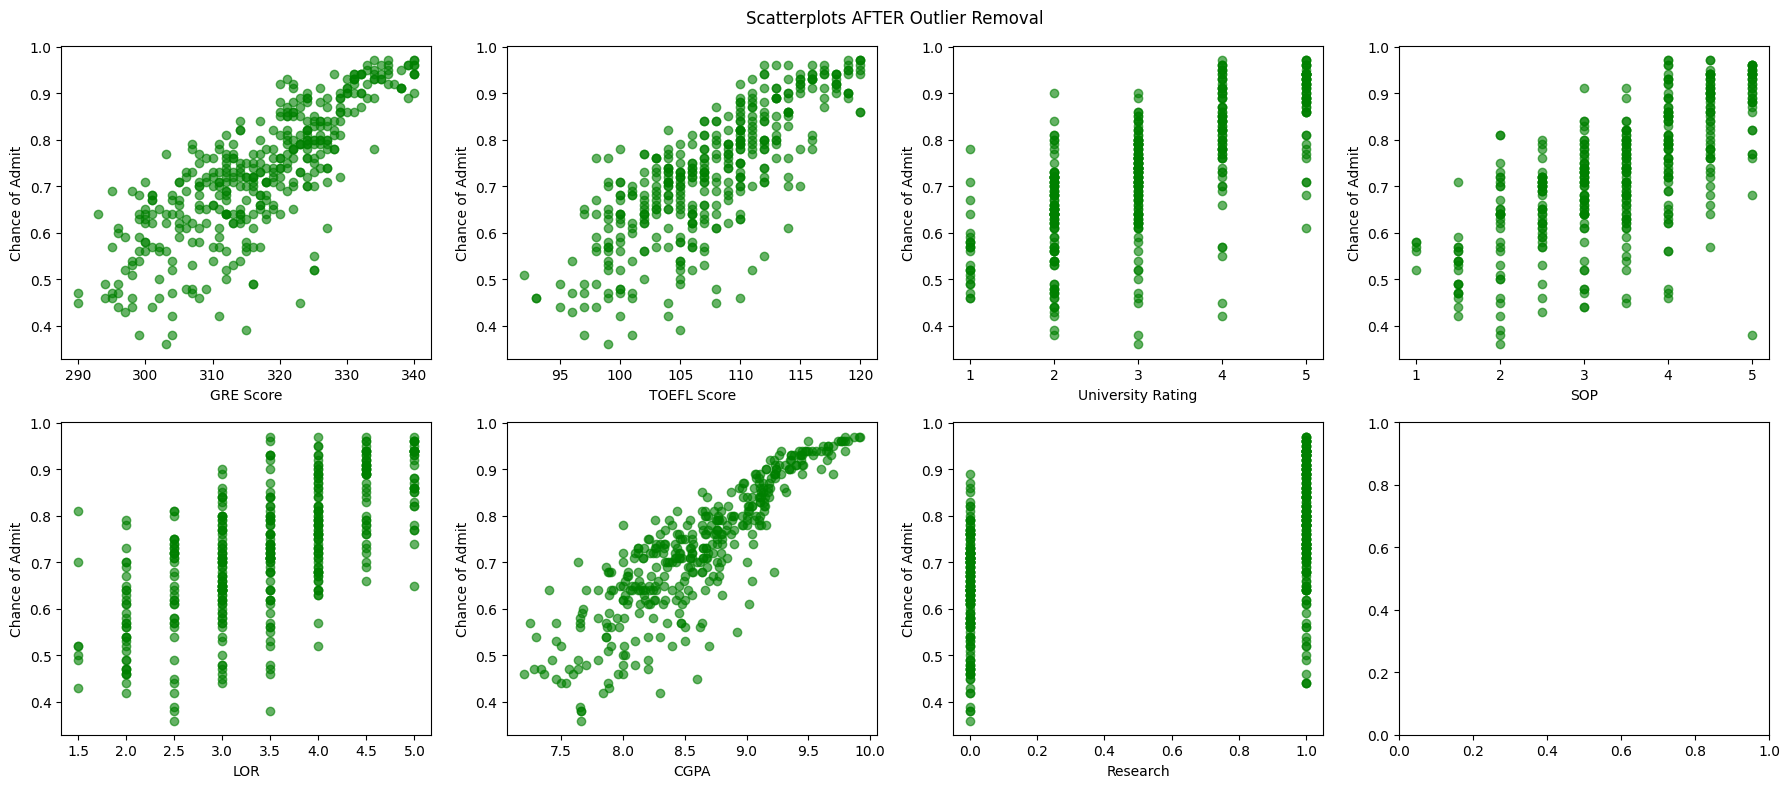

In [7]:
# Step 6: Scatterplots AFTER removing outliers
# The remaining points should follow the general trend more closely

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df_clean[col], df_clean["Chance of Admit"], alpha=0.6, color="green")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Chance of Admit")

plt.suptitle("Scatterplots AFTER Outlier Removal")
plt.tight_layout()
plt.show()

/tmp/ipykernel_477/4012014452.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df[c] for c in df.columns], labels=df.columns)
/tmp/ipykernel_477/4012014452.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_clean[c] for c in df_clean.columns], labels=df_clean.columns)


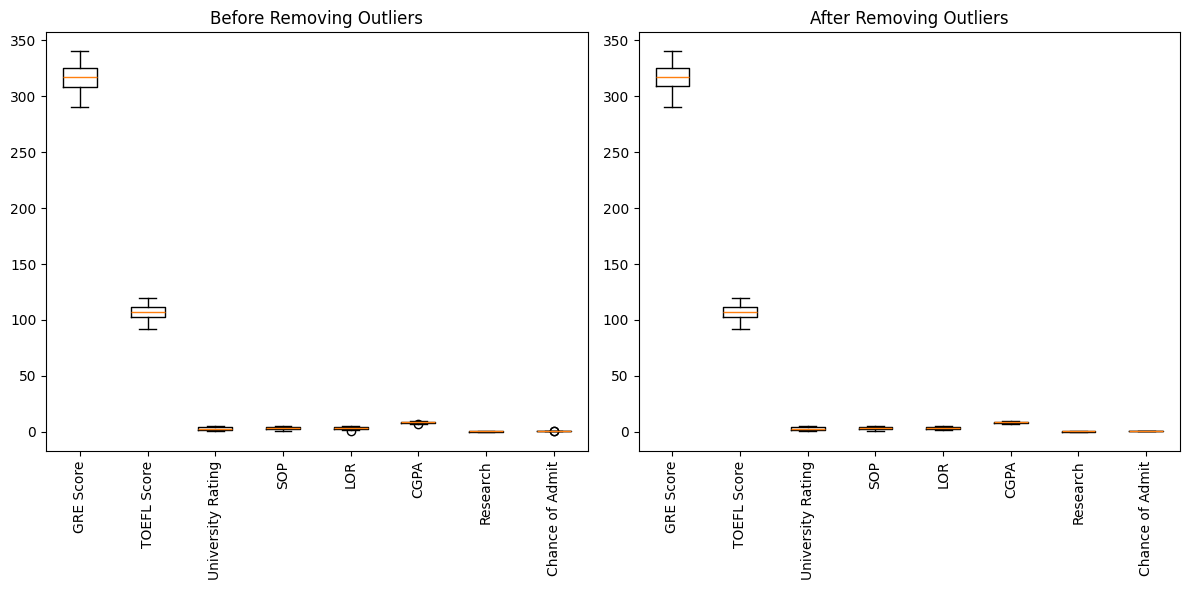

In [ ]:
# Step 7: Compare BEFORE vs AFTER side by side in one figure

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].boxplot([df[c] for c in df.columns], labels=df.columns)
axes[0].set_title("Before Removing Outliers")
axes[0].tick_params(axis='x', rotation=90)

axes[1].boxplot([df_clean[c] for c in df_clean.columns], labels=df_clean.columns)
axes[1].set_title("After Removing Outliers")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

